In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
datadir = '/Users/CDKoven/datasets/flat10MIP_analysis/'

exp_list = ['flat10','flat10-zec','flat10-cdr']


In [3]:
def monthly_to_annual(array):
    """calculate annual mena from monthly data, using unequal month lengths fros noleap calendar.
    originally written by Keith Lindsay."""
    mon_day = xr.DataArray(
        np.array([31.0, 28.0, 31.0, 30.0, 31.0, 30.0, 31.0, 31.0, 30.0, 31.0, 30.0, 31.0]),
        dims=["month"],
    )
    mon_wgt = mon_day / mon_day.sum()
    return (
        array.rolling(time=12, center=False)  # rolling
        .construct("month")  # construct the array
        .isel(
            time=slice(11, None, 12)
        )  # slice so that the first element is [1..12], second is [13..24]
        .dot(mon_wgt, dims=["month"])
    )

In [4]:
co2_flat10=pd.read_csv(datadir+'globalmean_output/atmospheric_co2_flat10.csv')
co2_flat10_zec=pd.read_csv(datadir+'globalmean_output/atmospheric_co2_flat10-zec.csv')
co2_flat10_cdr=pd.read_csv(datadir+'globalmean_output/atmospheric_co2_flat10-cdr.csv')


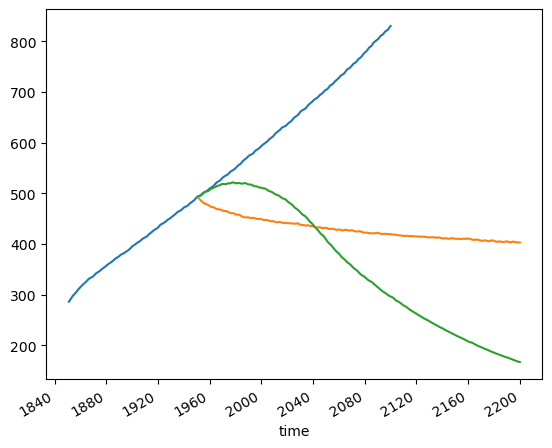

In [5]:
## #read miroc data which was not used or reported in Sanderson et al 2025 paper
miroc_co2_flat10 = xr.open_dataset(datadir+'flat10/miroc-es2l/flat10/co2_flat10_miroc-es2l.nc')
miroc_co2_flat10_zec = xr.open_dataset(datadir+'flat10/miroc-es2l/flat10_zec/co2_flat10zec_miroc-es2l.nc')
miroc_co2_flat10_cdr = xr.open_dataset(datadir+'flat10/miroc-es2l/flat10_cdr/co2_flat10cdr_miroc-es2l.nc')
monthly_to_annual(miroc_co2_flat10['co2']).plot()
monthly_to_annual(miroc_co2_flat10_zec['co2']).plot()
monthly_to_annual(miroc_co2_flat10_cdr['co2']).plot()

In [6]:
flat10_miroc_annual = monthly_to_annual(miroc_co2_flat10['co2'])
flat10_miroc_zec_annual = xr.concat((monthly_to_annual(miroc_co2_flat10['co2']).isel(time=slice(0,100)),monthly_to_annual(miroc_co2_flat10_zec['co2'])), dim='time')
flat10_miroc_cdr_annual = xr.concat((monthly_to_annual(miroc_co2_flat10['co2']).isel(time=slice(0,100)),monthly_to_annual(miroc_co2_flat10_cdr['co2'])), dim='time')

flat10_miroc_annual['time'] = np.arange(len(flat10_miroc_annual))
flat10_miroc_zec_annual['time'] = np.arange(len(flat10_miroc_zec_annual))
flat10_miroc_cdr_annual['time'] = np.arange(len(flat10_miroc_cdr_annual))

co2_flat10_zec['MIROC-ES2L'] = flat10_miroc_zec_annual.to_series()
co2_flat10['MIROC-ES2L'] = flat10_miroc_annual.to_series()
co2_flat10_cdr['MIROC-ES2L'] = flat10_miroc_cdr_annual.to_series()
        

In [7]:
### drop uvic model
co2_flat10 = co2_flat10.drop(columns='UVic-ESCM-2-10')
co2_flat10_zec = co2_flat10_zec.drop(columns='UVic-ESCM-2-10')
co2_flat10_cdr = co2_flat10_cdr.drop(columns='UVic-ESCM-2-10')


In [8]:
#co2_flat10['MPI-ESM1-2-LR']

# Remove brackets
co2_flat10['MPI-ESM1-2-LR'] = co2_flat10['MPI-ESM1-2-LR'].str.replace(r'[\[\]]', '', regex=True)
co2_flat10_zec['MPI-ESM1-2-LR'] = co2_flat10_zec['MPI-ESM1-2-LR'].str.replace(r'[\[\]]', '', regex=True)
co2_flat10_cdr['MPI-ESM1-2-LR'] = co2_flat10_cdr['MPI-ESM1-2-LR'].str.replace(r'[\[\]]', '', regex=True)

# Convert to numeric
co2_flat10['MPI-ESM1-2-LR'] = pd.to_numeric(co2_flat10['MPI-ESM1-2-LR'])
co2_flat10_zec['MPI-ESM1-2-LR'] = pd.to_numeric(co2_flat10_zec['MPI-ESM1-2-LR'])
co2_flat10_cdr['MPI-ESM1-2-LR'] = pd.to_numeric(co2_flat10_cdr['MPI-ESM1-2-LR'])



In [9]:
co2_flat10

,ACCESS-ESM1-5,CESM2,GFDL-ESM4,GISS,NorESM2-LM,MPI-ESM1-2-LR,CNRM-ESM2-1,UKESM,HadCM3LC-Bris,MIROC-ES2L
0,289.34045,284.584089,285.58770,286.599487,284.261336,284.90720,287.689641,290.9604,282.430818,285.829053
1,293.38358,288.691336,289.96948,290.904785,287.412365,288.40778,292.098804,294.4771,285.652423,289.808994
2,297.01860,292.525869,293.02606,294.892212,290.736814,292.49200,296.586503,297.7260,289.465875,294.182505
3,300.75018,295.907312,296.14130,297.893860,294.199266,296.45483,300.369114,300.6960,292.448046,297.601677
4,304.32303,299.198746,299.53485,301.382385,297.711142,298.98688,304.250018,303.4035,295.409123,300.265769
...,...,...,...,...,...,...,...,...,...,...
313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1166.2527,NaN,NaN
314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1169.3424,NaN,NaN
315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1174.2080,NaN,NaN
316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1177.6924,NaN,NaN


<Axes: >

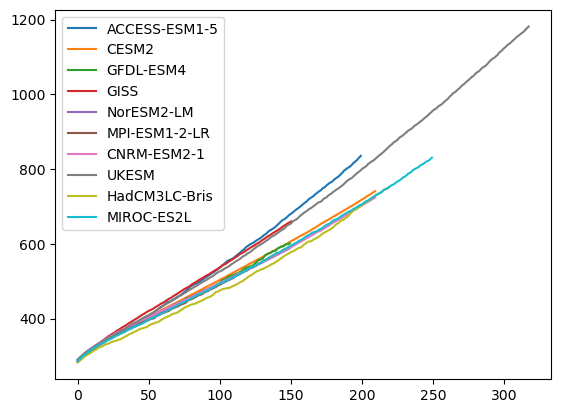

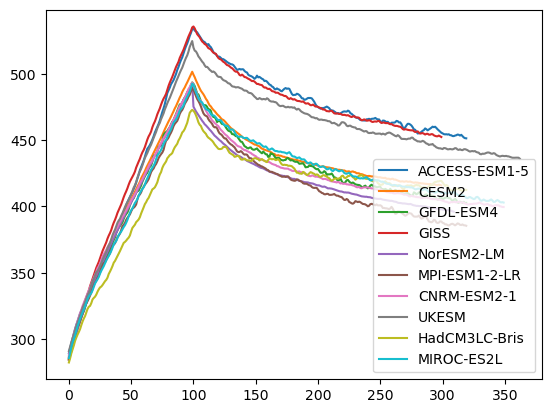

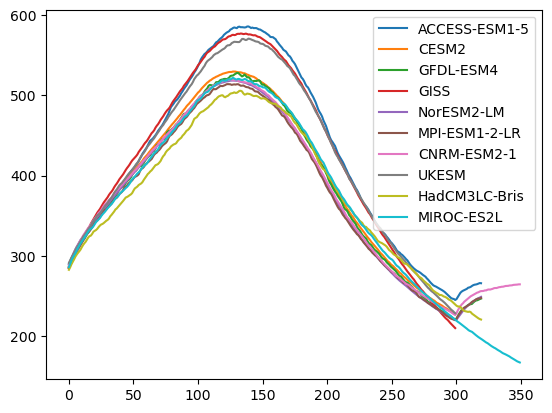

In [10]:
co2_flat10.plot()
co2_flat10_zec.plot()
co2_flat10_cdr.plot()

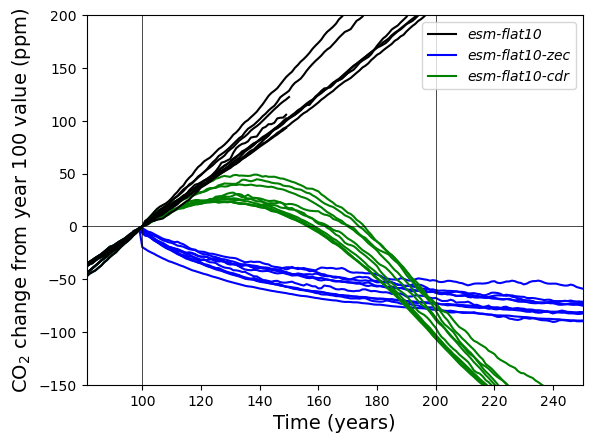

In [11]:
plt.plot(np.arange(len(co2_flat10_zec)), co2_flat10_zec - co2_flat10.iloc[100], c='blue')
plt.plot(np.arange(len(co2_flat10_cdr)), co2_flat10_cdr - co2_flat10.iloc[100], c='green')
plt.plot(np.arange(len(co2_flat10)), co2_flat10 - co2_flat10.iloc[100], c='black')

plt.plot([None],[None], c='black', label='esm-flat10')
plt.plot([None],[None], c='blue', label='esm-flat10-zec')
plt.plot([None],[None], c='green', label='esm-flat10-cdr')

plt.vlines((100,200), ymin=-200,ymax=600, color='black', linewidth=0.5)
plt.hlines((0), xmin=-200,xmax=600, color='black', linewidth=0.5)

plt.xlim(81., 250)
plt.ylim(-150., 200)

plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('CO$_2$ change from year 100 value (ppm)', fontsize=14)

plt.legend(prop={'style': 'italic'})

plt.savefig('fig_co2_timeseries.png', dpi=300, bbox_inches='tight')


In [12]:
print(co2_flat10_zec.iloc[200] - co2_flat10.iloc[100])
print((co2_flat10_zec.iloc[200] - co2_flat10.iloc[100]).mean())
print((co2_flat10_zec.iloc[200] - co2_flat10.iloc[100]).std())

ACCESS-ESM1-5   -62.104310
CESM2           -72.862245
GFDL-ESM4       -67.876980
GISS            -62.539307
NorESM2-LM      -78.981737
MPI-ESM1-2-LR   -78.021490
CNRM-ESM2-1     -73.157088
UKESM           -60.476500
HadCM3LC-Bris   -51.371632
MIROC-ES2L      -62.989500
dtype: float64
-67.03807888046359
8.723003566673658


In [13]:
print(co2_flat10_cdr.iloc[200] - co2_flat10.iloc[100])
print((co2_flat10_cdr.iloc[200] - co2_flat10.iloc[100]).mean())
print((co2_flat10_cdr.iloc[200] - co2_flat10.iloc[100]).std())

ACCESS-ESM1-5    -80.002590
CESM2           -102.780225
GFDL-ESM4        -96.214080
GISS             -86.641327
NorESM2-LM      -106.513186
MPI-ESM1-2-LR   -106.118620
CNRM-ESM2-1     -104.418973
UKESM            -74.839500
HadCM3LC-Bris    -73.106312
MIROC-ES2L       -88.715974
dtype: float64
-91.93507876310662
13.051269580033612


In [14]:
print(co2_flat10_cdr.iloc[200] - co2_flat10_zec.iloc[200])
print((co2_flat10_cdr.iloc[200] - co2_flat10_zec.iloc[200]).mean())
print((co2_flat10_cdr.iloc[200] - co2_flat10_zec.iloc[200]).std())

ACCESS-ESM1-5   -17.898280
CESM2           -29.917980
GFDL-ESM4       -28.337100
GISS            -24.102020
NorESM2-LM      -27.531450
MPI-ESM1-2-LR   -28.097130
CNRM-ESM2-1     -31.261885
UKESM           -14.363000
HadCM3LC-Bris   -21.734680
MIROC-ES2L      -25.726474
Name: 200, dtype: float64
-24.89699988264304
5.436552929012615


In [15]:
print((co2_flat10_zec.iloc[299] - co2_flat10.iloc[100]).mean())
print((co2_flat10_zec.iloc[299] - co2_flat10.iloc[100]).std())


-85.62743045799037
12.298774367502924


In [16]:
co2_flat10_cdr.iloc[200]

ACCESS-ESM1-5    456.958040
CESM2            401.024850
GFDL-ESM4        399.903500
GISS             450.873566
NorESM2-LM       388.429421
MPI-ESM1-2-LR    384.608920
CNRM-ESM2-1      390.998960
UKESM            451.424600
HadCM3LC-Bris    402.045714
MIROC-ES2L       405.254613
Name: 200, dtype: float64

In [17]:
co2_flat10_zec.iloc[299]

ACCESS-ESM1-5    455.544300
CESM2            415.896128
GFDL-ESM4        406.586900
GISS             452.336578
NorESM2-LM       397.849317
MPI-ESM1-2-LR    388.655940
CNRM-ESM2-1      404.695709
UKESM            443.570700
HadCM3LC-Bris    419.239666
MIROC-ES2L       410.223427
Name: 299, dtype: float64